DiffLogicClass.py copied below for easier debugging

### Class and Function declarations

##### Dependencies

In [92]:
import pandas as pd
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from difflogic import LogicLayer, GroupSum
import numpy as np
import matplotlib.pyplot as plt
from torchviz import make_dot
import sys

# used to train the DiffLogic models with different configs taken from config.yaml
from hydra import compose, initialize
from omegaconf import OmegaConf, DictConfig
import torch
import os
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

# Fix random seeds for reproducibility
torch.manual_seed(42)             # PyTorch seed fixing
torch.cuda.manual_seed(42)        # PyTorch CUDA seed fixing (if using GPU)
np.random.seed(42)                # NumPy seed fixing
random.seed(42)                   # Python's built-in random seed fixing

# If using CUDA:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

##### Dataset

In [118]:
class DataProcessor:
    def __init__(self, file_path, data_id='data_id', state_id='state_id', test_size=0.2, batch_size=32, random_state=42):
        """
        Initializes the DataProcessor, loads the data, processes it, and splits it into training and testing datasets.

        Args:
            file_path (str): Path to the CSV file containing the data.
            data_id (str): Column name for feature data.
            state_id (str): Column name for label data.
            test_size (float): Fraction of the data to be used as the test set.
            batch_size (int): Number of samples per batch.
            random_state (int): Seed for the random number generator.
        """
        self.file_path = file_path
        self.data_id = data_id
        self.state_id = state_id
        self.test_size = test_size
        self.batch_size = batch_size
        self.random_state = random_state
        self.scaler = StandardScaler() 
        self.train_loader, self.test_loader = self.load_and_split_data()
        
    def process_chunk(self, data, variable):
        """
        Processes a chunk of data and converts it into tensors. The processing differs based on the data type (features or labels).

        Args:
            data (pandas.Series): A series object containing the data to be processed.
            variable (bool): If False, process as feature data (X); if True, process as label data (y).

        Returns:
            List[torch.Tensor]: A list of tensors corresponding to the processed data.
        """
        tensors = []
        if not variable:
            data = data.apply(lambda x: x.replace('\n', '').replace('[', '').replace(']', '').replace('.', '').split())
            data = data.apply(lambda x: [float(num) for num in x])
            tensors = [torch.tensor(entry, dtype=torch.float64).view(20, 3) for entry in data]
        else:
            data = data.apply(lambda x: eval(x))
            tensors = [torch.tensor(entry) for entry in data]
        return tensors

    def data_conversion_csv(self, column_name, variable, chunksize=10000):
        """
        A generator function that reads data from a CSV in chunks and processes it.

        Args:
            column_name (str): The name of the column to read data from.
            variable (bool): Determines how the data should be processed (as features or labels).
            chunksize (int): Number of rows per chunk.

        Yields:
            Iterator over processed data tensors.
        """
        for chunk in pd.read_csv(self.file_path, usecols=[column_name], chunksize=chunksize):
            yield from self.process_chunk(chunk[column_name], variable)

    def normalize_data(self, X_data):
        """
        Normalizes the input data using StandardScaler.

        Args:
            X_data (List[torch.Tensor]): List of tensors containing the input data.

        Returns:
            List[torch.Tensor]: List of normalized tensors.
        """
        # Convert list of tensors to a single tensor for normalization
        X_concat = torch.cat([x.view(-1, 3) for x in X_data])
        
        # Fit the scaler on the training data
        self.scaler.fit(X_concat.cpu().numpy())

        # Normalize each tensor
        X_normalized = []
        for x in X_data:
            x_normalized = torch.tensor(self.scaler.transform(x.view(-1, 3).cpu().numpy()), dtype=torch.float64, device=x.device)
            X_normalized.append(x_normalized.view(20, 3))
        
        return X_normalized

    def load_and_split_data(self):
        """
        Loads and processes data from a CSV file into tensors for features and labels, then splits them into training and testing sets.

        Returns:
            tuple: A tuple containing the DataLoader for training and testing datasets.
        """
        X_data = list(self.data_conversion_csv(self.data_id, False))
        y_data = list(self.data_conversion_csv(self.state_id, True))
        
        # Normalize the input features
        #X_data = self.normalize_data(X_data)
        
        X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=self.test_size, random_state=self.random_state)
        X_train_tensor, X_test_tensor = torch.stack(X_train), torch.stack(X_test)
        y_train_tensor, y_test_tensor = torch.stack(y_train), torch.stack(y_test)
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        
        # Create DataLoaders with the specified batch size
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)

        return train_loader, test_loader

In [119]:
dataset_path = "/blue/woodard/share/skeptical_beings/training_datasets/schoolhouse_dataset_e2_2024.06.14.csv"    
dloader = DataProcessor(file_path=dataset_path, batch_size=256)
train_loader, test_loader = dloader.train_loader, dloader.test_loader

##### DiffLogicClass

In [120]:
class DiffLogic(nn.Module):
    def __init__(self, layers_config, output_size=3, tau=30):
        """
        Initializes the DiffLogic model with the specified layer configurations, output size, and temperature parameter.

        Args:
            layers_config (dict): Configuration for each logic layer, including dimensions, device, implementation, connections, and grad factor.
            output_size (int): The number of output groups.
            tau (int): Temperature parameter for the GroupSum operation.
        """
        super(DiffLogic, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        for layer_name, config in layers_config.items():
            layer = LogicLayer(
                in_dim=config['in_dim'],
                out_dim=config['out_dim'],
                device=config['device'],
                implementation=config['implementation'],
                connections=config['connections'],
                grad_factor=config['grad_factor']       
            )
            layers.append(layer)
            print(layer)
        
        self.logic_layers = nn.Sequential(*layers)
        
        self.group = GroupSum(k=output_size, tau=tau)
    
    def forward(self, x):
        """
        Forward pass of the DiffLogic model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor after processing through the logic layers and grouping operation.
        """
        # Move tensor to GPU
        if torch.cuda.is_available():
            x = x.to('cuda')          
        x = self.flatten(x)
        logits = self.logic_layers(x)
        group = self.group(logits)
        return group

##### OverallModelClass

In [121]:
class Model(nn.Module):
    def __init__(self, cfg, num_classes):
        """
        Initializes the Model, loads the DiffLogic model, sets up the optimizer, loss function, and other necessary configurations.

        Args:
            cfg (dict): Configuration dictionary containing model parameters such as layer configurations, output size, tau, and learning rate.
            num_classes (int): Number of classes in the classification task.
        """
        super(Model, self).__init__()
        
        self.layers_config = cfg["layers_config"]
        self.output_size = cfg["output_size"]
        self.tau = cfg["tau"]
        self.num_classes = num_classes        
                
        self.diff_logic_model = DiffLogic(self.layers_config, output_size=self.output_size, tau=self.tau)
        self.optimizer = torch.optim.Adam(self.diff_logic_model.parameters(), lr=cfg["learning_rate"])
        self.criterion = nn.CrossEntropyLoss() # loss function for classification tasks

    def forward(self, input_data):    
        """
        Forward pass to predict the model output.

        Args:
            input_data (torch.Tensor): Input data tensor.
            
        Returns:
            torch.Tensor: The predicted output tensor with class probabilities.
        """
        output = self.diff_logic_model(input_data)
        print(output)
        output = output.view(-1, self.output_size, self.num_classes)  # Reshape to [batch_size, output_size, num_classes]
        return output

    def loss(self, predictions, labels):
        """
        Computes the loss between the predicted and true labels.

        Args:
            predictions (torch.Tensor): Predicted tensor output from the model.
            labels (torch.Tensor): True labels tensor.

        Returns:
            torch.Tensor: The computed loss value.
        """
        # CrossEntropyLoss expects predictions in [batch_size, num_classes] and labels in [batch_size]
        losses = []
        for i in range(self.output_size):
            losses.append(self.criterion(predictions[:, i, :], labels[:, i]))
        return sum(losses) / len(losses)
    
    def step(self):
        """
        Updates the model parameters by performing a single optimization step.

        Returns:
            None
        """
        self.optimizer.step()

    def test_train(self, prediction_dict):
        """
        Training method for system development on a dummy dataset.

        Args:
            prediction_dict (dict): Dictionary containing predicted and true output data.

        Returns:
            torch.Tensor: The computed loss.
        """
        self.optimizer.zero_grad()
        predictions = self.forward(prediction_dict["input_data"])
        loss = self.loss(predictions, prediction_dict["true_output_data"])  # Structure loss
        return loss

    def save(self, file_path, model_name='model'):
        """
        Saves the model's state dictionary to the specified file path.

        Args:
            file_path (str): Path where the model will be saved.
            model_name (str): Name of the saved model

        Returns:
            None
        """
        torch.save({
            'model_state_dict': self.diff_logic_model.state_dict(),
            'connections': [layer.indices for layer in self.diff_logic_model.logic_layers if isinstance(layer, LogicLayer)]
        }, os.path.join(file_path, f"{model_name}.pth"))
        self.log_text += f"Model saved to: {file_path}\n"

    def load(self, file_path):
        """
        Loads the model's state dictionary from the specified file path.

        Args:
            file_path (str): Path from which the model will be loaded.

        Returns:
            None
        """
        checkpoint = torch.load(file_path)
        self.diff_logic_model.load_state_dict(checkpoint['model_state_dict'])

        # Assign connections to each LogicLayer
        for idx, layer in enumerate(self.diff_logic_model.logic_layers):
            if isinstance(layer, LogicLayer):
                layer.indices = checkpoint['connections'][idx]

        self.diff_logic_model.eval()
        self.log_text += f"Model loaded from: {file_path}\n"

    def plot_loss(self, loss_history):
        """
        Plots the training loss over epochs.

        Args:
            loss_history (list): List containing the loss values for each epoch.

        Returns:
            None
        """
        plt.figure()
        plt.plot(loss_history, label='Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Epochs')
        plt.legend()
        plt.show()
        self.log_text += "Loss plot generated\n"

    def visualize_model(self):
        """
        Generates a visualization of the model using a dummy input.

        Returns:
            None
        """
        dummy_input = torch.randn(1, cfg["input_dim"])  # Adjust this as needed based on your input dimensions
        y = self.diff_logic_model(dummy_input)
        g = make_dot(y, params=dict(self.diff_logic_model.named_parameters()))
        g.view()
        self.log_text += "Model visualization generated\n"

    def explain(self):
        """
        Placeholder function for explaining the model's decisions.

        Returns:
            None
        """
        return None
    
    def get_accuracy(self, data_loader):
        """
        Calculates the accuracy of the model against a data loader
        
        Args:
            data_loader: a DataLoader object, e.g. train_loader or test_loader
            
        Returns:
            float: The accuracy
        """
        correct = 0
        total = 0
    
        # Ensure model is in evaluation mode
        self.diff_logic_model.eval()

        with torch.no_grad():  # Disable gradient calculation for inference
            for batch_inputs, batch_outputs in tqdm(data_loader, desc="Running Inference"):
                batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

                # Forward pass to get predictions
                predictions = self.diff_logic_model(batch_inputs)
                predictions = predictions.view(-1, self.output_size, self.num_classes)
                predicted_classes = torch.argmax(predictions, dim=2)

                # Comparing predicted classes to actual targets
                correct += (predicted_classes == batch_outputs).all(dim=1).sum().item()
                total += batch_outputs.size(0)  # Total number of samples in the batch

        accuracy = correct / total
        return accuracy

##### EarlyStopper Class

In [104]:
class EarlyStopper:
    def __init__(self, patience=10, min_delta=0):
        """
        Initializes the EarlyStopper to stop training if the performance doesn't improve after a certain number of epochs.

        Args:
            patience (int): Number of epochs to wait for an improvement.
            min_delta (float): Minimum change to consider an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def should_stop(self, current_loss):
        """
        Check if training should stop based on the current loss.

        Args:
            current_loss (float): The current loss.

        Returns:
            bool: True if training should stop, False otherwise.
        """
        if self.best_loss is None:
            self.best_loss = current_loss
            return False
        elif current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            print("EarlyStopper Triggered: ", self.counter)
            if self.counter >= self.patience:
                return True
            return False

##### Accuracy Function

In [105]:
def calculate_accuracy(model, test_loader):
    correct = 0
    total = 0
    model.eval()
    
    with torch.no_grad():  # Disable gradient calculation for inference
        for batch_inputs, batch_outputs in tqdm(test_loader, desc="Running Inference"):
            batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

            # Forward pass to get predictions
            predictions = model(batch_inputs)
            
            # Rounding the outputs to the nearest integer
            rounded_predictions = torch.round(predictions).long()
            
            if True:
                print(predictions[0])
                print(rounded_predictions[0])
                print(batch_outputs[0])
                print()

            # Comparing rounded predictions to actual targets
            correct += (rounded_predictions == batch_outputs).all(dim=1).sum().item()
            total += batch_outputs.size(0)  # Total number of samples in the batch

    accuracy = correct / total
    return accuracy

##### Function to test config.yaml

In [31]:
def func(model_cfg: DictConfig):
    working_dir = os.getcwd()
    #print(f"The current working directory is {working_dir}")

    # Access model-specific elements of the config
    print(f"The input dimension is {model_cfg.input_dim}")
    print(f"The learning rate is {model_cfg.learning_rate}")
    print(f"The Logic Layers are:")
    for layer_name in model_cfg.layers_config.items():
        print("\t", layer_name)

if __name__ == "__main__":
    # Initialize Hydra with the config path and job name
    with initialize(version_base=None, config_path="config", job_name="test_app"):
        cfg = compose(config_name="skeptic_config")
        
    # Access all models in config.yaml
    for model_name, model_cfg in cfg.models.items():
        print(f"\n\nProcessing {model_name}")
        func(model_cfg)



Processing model_001
The input dimension is 60
The learning rate is 0.0001
The Logic Layers are:
	 ('LogicLayer001', {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 60, 'out_dim': 99999})


Processing model_002
The input dimension is 60
The learning rate is 0.0001
The Logic Layers are:
	 ('LogicLayer001', {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 60, 'out_dim': 20001})
	 ('LogicLayer002', {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 20001, 'out_dim': 20001})
	 ('LogicLayer003', {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 20001, 'out_dim': 20001})
	 ('LogicLayer004', {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 20001, 'out_dim': 20001})
	 ('LogicLayer005', {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'imple

#### Single Model

##### Training

In [122]:
from tqdm import tqdm
losses = []
model_name = 'model_001'
num_classes = 20

# Initialize Hydra with the config path and job name
with initialize(version_base=None, config_path="config", job_name="test_app"):
    # Compose the configuration by specifying the config name
    cfg = compose(config_name="skeptic_config")

# Access the configuration for a specific model (e.g., model_001)
model_cfg = cfg.models[model_name]
print(model_cfg)

{'input_dim': 60, 'layers_config': {'LogicLayer001': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 60, 'out_dim': 600}}, 'learning_rate': 0.01, 'output_size': 3, 'tau': 10}


In [124]:
model = Model(model_cfg, num_classes).to('cuda')

# Initialize EarlyStopper with a patience of 10 epochs
early_stopper = EarlyStopper(patience=10)

num_epochs = 10
losses = []

for epoch in range(num_epochs):
    loop = tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
    epoch_loss = 0  # Track loss for the entire epoch
    
    for batch_inputs, batch_outputs in loop:
        # Move to GPU if available
        batch_inputs, batch_outputs = batch_inputs.to('cuda').double(), batch_outputs.to('cuda').double()
        
        # Create prediction dictionary
        prediction_dict = {
            "input_data": batch_inputs, 
            "true_output_data": batch_outputs
        }
                
        print(batch_inputs.shape)
        
        # Forward pass
        model.optimizer.zero_grad()
        predictions = model.forward(batch_inputs)

        # Update the prediction_dict with the model's predictions
        prediction_dict["pred_output_data"] = predictions
            
        # Compute the loss
        loss = model.test_train(predictions, batch_outputs)
        
        # Zero gradients, backpropagate, and update the model parameters
        loss.backward()
        model.step()

        # Accumulate the batch loss
        epoch_loss += loss.item()
    
    # Calculate the average loss for the epoch
    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    print(f'Epoch {epoch+1} Loss: {epoch_loss}')

    # Check if we should stop early
    if early_stopper.should_stop(epoch_loss):
        print(f"Early stopping triggered at epoch {epoch+1}. Training stopped.")
        break

# Save the model after training completes
FILE_PATH = 'trained_models'
FILE_NAME = f'{model_name}_weights'
model.save(FILE_PATH, FILE_NAME)

LogicLayer(60, 600, train)


Epoch 1/10:   0%|          | 0/238 [00:00<?, ?it/s]

torch.Size([256, 20, 3])
tensor([[10.2640,  8.8650, 10.6152],
        [ 9.4773,  8.8344,  9.7528],
        [ 9.5387, 10.2675,  9.7928],
        [10.0187,  9.2690,  9.9032],
        [10.3018,  9.3527,  9.7391],
        [ 9.4983,  9.2079,  9.6247],
        [ 9.8971,  9.6115,  9.7700],
        [ 9.9536,  9.3039,  9.7880],
        [10.2345, 11.4632, 12.2487],
        [10.4813,  9.3768, 10.6931],
        [10.4681,  9.1009,  9.8466],
        [ 9.8485, 10.2400,  9.8011],
        [ 9.8887, 10.0174, 10.5202],
        [ 9.3405,  9.4582,  9.9498],
        [ 9.6775,  9.3913, 10.0433],
        [10.4843,  9.6933,  9.9158],
        [10.0612,  9.2247, 10.1981],
        [10.8581,  9.5860,  9.6646],
        [10.7950,  9.0744,  9.8501],
        [ 9.3933,  9.5971,  9.3817],
        [10.6602,  8.4946, 10.1250],
        [ 9.9259,  9.4626, 10.4558],
        [ 9.6259, 10.0201, 10.0551],
        [10.0848,  9.7092, 10.4578],
        [ 9.0116,  9.7698,  9.2982],
        [ 9.0679,  7.8996,  9.2294],
        [10.0

RuntimeError: shape '[-1, 3, 20]' is invalid for input of size 768

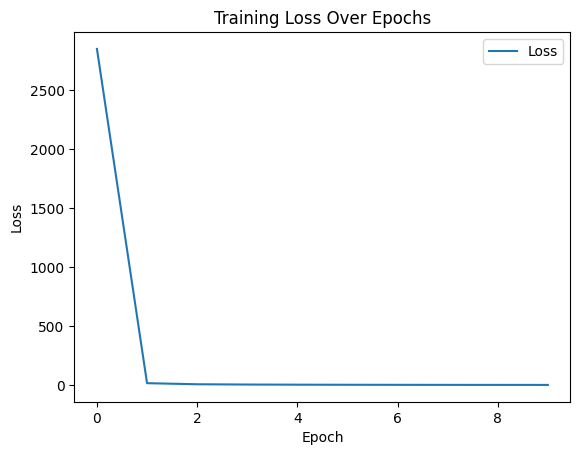

In [86]:
model.diff_logic_model.eval()
model.plot_loss(losses)

In [87]:
torch.tensor(model.diff_logic_model((prediction_dict['input_data']))[0]).long(), prediction_dict['true_output_data'][0]             

/scratch/local/43215085/ipykernel_1763371/1622321740.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(model.diff_logic_model((prediction_dict['input_data']))[0]).long(), prediction_dict['true_output_data'][0]


(tensor([-156, 1284, -233], device='cuda:0'),
 tensor([3., 4., 4.], device='cuda:0', dtype=torch.float64))

In [74]:
index = 0
model.diff_logic_model.eval()
torch.tensor(model.diff_logic_model((prediction_dict['input_data']))[0]).long(), prediction_dict['true_output_data'][0]             

/scratch/local/43215085/ipykernel_1763371/3296133539.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(model.diff_logic_model((prediction_dict['input_data']))[0]).long(), prediction_dict['true_output_data'][0]


(tensor([   27, -1466, -1639], device='cuda:0'),
 tensor([2., 1., 1.], device='cuda:0', dtype=torch.float64))

In [69]:
model.get_accuracy(test_loader)

Running Inference: 100%|██████████| 60/60 [00:00<00:00, 129.60it/s]


0.0

In [75]:
accuracy = calculate_accuracy(model.diff_logic_model, test_loader)
accuracy

Running Inference:  38%|███▊      | 23/60 [00:00<00:00, 114.50it/s]

tensor([  -223.0667, -14180.0667,   -307.5667], device='cuda:0',
       dtype=torch.float64)
tensor([  -223, -14180,   -308], device='cuda:0')
tensor([2, 3, 1], device='cuda:0')

tensor([-5923.5000,   305.8333, -3918.8667], device='cuda:0',
       dtype=torch.float64)
tensor([-5924,   306, -3919], device='cuda:0')
tensor([1, 1, 2], device='cuda:0')

tensor([ -1111.1000, -10047.2333,     15.2000], device='cuda:0',
       dtype=torch.float64)
tensor([ -1111, -10047,     15], device='cuda:0')
tensor([2, 1, 2], device='cuda:0')

tensor([  1237.5000, -23181.3000,   5586.0333], device='cuda:0',
       dtype=torch.float64)
tensor([  1238, -23181,   5586], device='cuda:0')
tensor([1, 3, 1], device='cuda:0')

tensor([-1304.1333,  -201.3333,    16.1333], device='cuda:0',
       dtype=torch.float64)
tensor([-1304,  -201,    16], device='cuda:0')
tensor([2, 1, 3], device='cuda:0')

tensor([  129.5667, -5721.1667, -2239.9000], device='cuda:0',
       dtype=torch.float64)
tensor([  130, -5721, -2240

Running Inference:  85%|████████▌ | 51/60 [00:00<00:00, 129.89it/s]

tensor([-1.4267e+08, -1.4391e+08,  5.4847e+07], device='cuda:0',
       dtype=torch.float64)
tensor([-142666378, -143908596,   54847052], device='cuda:0')
tensor([3, 4, 4], device='cuda:0')

tensor([-4565.1333,    33.1333, -3860.0667], device='cuda:0',
       dtype=torch.float64)
tensor([-4565,    33, -3860], device='cuda:0')
tensor([3, 1, 1], device='cuda:0')

tensor([ 1298.2667, -1525.4333, -2376.1333], device='cuda:0',
       dtype=torch.float64)
tensor([ 1298, -1525, -2376], device='cuda:0')
tensor([2, 1, 1], device='cuda:0')

tensor([ 4383.2000,  -542.6333, -1582.3000], device='cuda:0',
       dtype=torch.float64)
tensor([ 4383,  -543, -1582], device='cuda:0')
tensor([2, 2, 3], device='cuda:0')

tensor([ -333.0000, -3021.6000,   410.2333], device='cuda:0',
       dtype=torch.float64)
tensor([ -333, -3022,   410], device='cuda:0')
tensor([2, 1, 2], device='cuda:0')

tensor([  -23.2333,   167.3667, -1158.3333], device='cuda:0',
       dtype=torch.float64)
tensor([  -23,   167, -1158

Running Inference: 100%|██████████| 60/60 [00:00<00:00, 127.97it/s]

tensor([ -1133.5000, -27313.5333,  49168.9333], device='cuda:0',
       dtype=torch.float64)
tensor([ -1134, -27314,  49169], device='cuda:0')
tensor([1, 1, 2], device='cuda:0')

tensor([780119.4000, 554117.4333, 445607.9000], device='cuda:0',
       dtype=torch.float64)
tensor([780119, 554117, 445608], device='cuda:0')
tensor([3, 2, 1], device='cuda:0')

tensor([-338.2667, 1775.1000,  929.2333], device='cuda:0', dtype=torch.float64)
tensor([-338, 1775,  929], device='cuda:0')
tensor([2, 1, 1], device='cuda:0')

tensor([  533.4667, -8413.2000,  4041.0667], device='cuda:0',
       dtype=torch.float64)
tensor([  533, -8413,  4041], device='cuda:0')
tensor([2, 1, 2], device='cuda:0')

tensor([599.0333, 811.2000, 745.8000], device='cuda:0', dtype=torch.float64)
tensor([599, 811, 746], device='cuda:0')
tensor([1, 3, 1], device='cuda:0')

tensor([-1814609.3000,    13165.8667,    71797.1333], device='cuda:0',
       dtype=torch.float64)
tensor([-1814609,    13166,    71797], device='cuda:0')


0.0

##### Inference

In [58]:
model_name = 'model_001'
model_name_config = model_name # from skeptic_config.yaml
model_name_weights = f'{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models'
PATH = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "skeptic_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="skeptic_config")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = Model(model_cfg).to('cuda')
model.load(PATH)

model.get_accuracy(test_loader)

LogicLayer(60, 99999, train)


Running Inference: 100%|██████████| 238/238 [00:02<00:00, 101.23it/s]


1.6468495767596588e-05

#### Multiple Models

##### Training

In [88]:
all_models_dict = {}
num_epochs = 10
file_path = 'trained_models'
metadata_file_path = 'trained_models_metadata'

# Initialize Hydra with the config path and job name
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="skeptic_config")

for model_name, model_cfg in cfg.models.items():
    print(f'training model {model_name}')

    # Initialize the dictionary entry for the model with an empty list for losses and other features
    all_models_dict[model_name] = {
        'losses': [],
        # Add other features here, e.g., 'accuracy': [], 'other_feature': []
    }

    try:
        # Initialize the model
        model = Model(model_cfg).to('cuda')
        optimizer = model.optimizer  
        
        # Initialize EarlyStopper for each model
        early_stopper = EarlyStopper(patience=10)  # Adjust patience as needed

        for epoch in range(num_epochs):
            loop = tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
            epoch_loss = 0  # Track the loss for the epoch
            
            for batch_inputs, batch_outputs in loop:
                # Move to GPU if available
                batch_inputs, batch_outputs = batch_inputs.to('cuda').double(), batch_outputs.to('cuda').double()

                # Create prediction dictionary
                prediction_dict = {
                    "input_data": batch_inputs, 
                    "true_output_data": batch_outputs
                }

                # Forward pass
                model.forward(prediction_dict)

                # Compute the loss
                loss = model.test_train(prediction_dict)

                # Zero gradients, backpropagate, and update the model parameters
                model.optimizer.zero_grad()
                loss.backward()
                model.step()
                
                # Accumulate loss for the epoch
                epoch_loss += loss.item()

            # Calculate average loss for the epoch
            epoch_loss /= len(train_loader)
            all_models_dict[model_name]['losses'].append(epoch_loss)
            print(f'Epoch {epoch+1} Loss: {epoch_loss}')

            # Check for early stopping
            if early_stopper.should_stop(epoch_loss):
                print(f"Early stopping triggered for {model_name} at epoch {epoch+1}.")
                break

        # Save the trained model
        model.save(file_path, model_name)
        
        # Get Model accuracy on test dataset
        model.get_accuracy(test_loader)

        # Save the trained model metadata
        #save_model_state(model, optimizer, model_cfg, all_models_dict, metadata_file_path, model_name, num_epochs, batch_size)        
    
    except Exception as e:
        print(f"ERROR TRAINING {model_name.upper()}: {str(e)}")

print("All models processed.")

training model model_001
LogicLayer(60, 99999, train)


Epoch 1/10: 100%|██████████| 238/238 [00:06<00:00, 35.37it/s]


Epoch 1 Loss: 479930.37721206696


Epoch 2/10: 100%|██████████| 238/238 [00:06<00:00, 34.84it/s]


Epoch 2 Loss: 13515.480131144937


...

Epoch 6 Loss: 126828.29197559229


Epoch 7/10: 100%|██████████| 238/238 [00:06<00:00, 39.27it/s]


Epoch 7 Loss: 119784.07179640917


Epoch 8/10:  37%|███▋      | 88/238 [00:02<00:04, 33.19it/s]


KeyboardInterrupt: 

##### Inference

In [91]:
trained_models_dir = 'trained_models'

# Get a list of all model files in the directory
model_files = sorted([f for f in os.listdir(trained_models_dir) if f.endswith('.pth')])

with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="skeptic_config")

# Loop through all model files and calculate their accuracies
for model_file in model_files:
    model_name = model_file.removesuffix('.pth')
    model_cfg = cfg['models'][model_name]
    
    # instantiate the model and load its weights
    model = Model(model_cfg).to('cuda')
    
    model_path = os.path.join(trained_models_dir, model_file)
    print(f"Evaluating {model_file}...")

    # Load the model
    model.load(model_path)

    model.diff_logic_model.eval()
    
    print(model.get_accuracy(train_loader), model.get_accuracy(test_loader))
    
    # Calculate accuracy
    #accuracy = calculate_accuracy(model.diff_logic_model, test_loader)
    
    print(f"Accuracy of {model_file}: {accuracy * 100:.2f}%\n")

LogicLayer(60, 99999, train)
Evaluating model_001.pth...


Running Inference: 100%|██████████| 60/60 [00:00<00:00, 107.21it/s]


0.0 0.0
Accuracy of model_001.pth: 0.00%

LogicLayer(60, 20001, train)
LogicLayer(20001, 20001, train)
LogicLayer(20001, 20001, train)
LogicLayer(20001, 20001, train)
LogicLayer(20001, 20001, train)
Evaluating model_002.pth...


Running Inference: 100%|██████████| 60/60 [00:00<00:00, 154.05it/s]


0.0 0.0
Accuracy of model_002.pth: 0.00%

LogicLayer(60, 9999, train)
LogicLayer(9999, 9999, train)
LogicLayer(9999, 9999, train)
LogicLayer(9999, 9999, train)
LogicLayer(9999, 9999, train)
LogicLayer(9999, 9999, train)
LogicLayer(9999, 9999, train)
LogicLayer(9999, 9999, train)
LogicLayer(9999, 9999, train)
LogicLayer(9999, 9999, train)
Evaluating model_003.pth...


...

0.0 0.0
Accuracy of model_023.pth: 0.00%

LogicLayer(60, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)
LogicLayer(2001, 2001, train)


Running Inference: 100%|██████████| 60/60 [00:00<00:00, 93.87it/s]


0.0 0.0
Accuracy of model_024.pth: 0.00%

LogicLayer(60, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLayer(999, 999, train)
LogicLa

Running Inference: 100%|██████████| 60/60 [00:00<00:00, 67.99it/s]

0.0 0.0
Accuracy of model_025.pth: 0.00%

